# Fase 4-E (4B) - Regionalizacao orientada por dados: cluster das pixelizacoes significativas

**Metodo: estatistico** (clusterizacao hierarquica Ward com restricao de contiguidade espacial; sem ML supervisionado).

Pipeline: assinatura de teleconexao por pixel (r e lag por estacao, do notebook D) -> seleciona pixels significativos (FDR) -> **Ward + contiguidade** -> escolhe k por silhueta -> valida cada regiao por **indice regional x Nino 3.4** (lead/sinal/estacao). Substitui as caixas NE/Sul "a mao" por regioes descobertas dos dados.

In [1]:
import sys, glob, time, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, xarray as xr
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_extraction.image import grid_to_graph
from sklearn.metrics import silhouette_score
ROOT=Path.cwd()
while ROOT!=ROOT.parent and not (ROOT/'pyproject.toml').exists(): ROOT=ROOT.parent
sys.path.insert(0,str(ROOT/'scripts')); import fase4_features as F
plt.rcParams.update({'figure.dpi':110,'axes.grid':True,'grid.alpha':0.3,'font.size':9})
Y0,Y1=1981,2025; PERIODO=(f'{Y0}-09-01',f'{Y1}-12-31')
SEASONS={'DJF':[12,1,2],'MAM':[3,4,5],'JJA':[6,7,8],'SON':[9,10,11]}
LAGS=range(0,7)
OUT=F.STATS/'phase4_E_regioes'; OUT.mkdir(parents=True,exist_ok=True)
NC=F.STATS/'phase4_D_semanal'/'mapa_propagacao_brasil_por_estacao.nc'
def report(df,name): df.to_csv(OUT/f'{name}.csv',index=False); print(f'[csv: phase4_E_regioes/{name}.csv]'); return df
print('setup ok')

setup ok


## 1. Assinatura de teleconexao por pixel (do notebook D)

Atributos por pixel: `r` e `lag` (em meses) de cada estacao -> 8 dimensoes. Pixel entra no cluster se for significativo (FDR) em **pelo menos uma** estacao.

In [2]:
ds=xr.open_dataset(NC); lats=ds['lat'].values; lons=ds['lon'].values; ny,nx=len(lats),len(lons)
feat_names=[]; layers=[]
for s in SEASONS:
    layers.append(np.nan_to_num(ds[f'{s}_r_pico'].values)); feat_names.append(f'r_{s}')
for s in SEASONS:
    layers.append(np.nan_to_num(ds[f'{s}_lag_meses'].values)); feat_names.append(f'lag_{s}')
feats=np.stack(layers,axis=-1)                                  # (ny,nx,8)
anysig=np.zeros((ny,nx),bool)
for s in SEASONS: anysig |= (ds[f'{s}_mask_fdr'].values==1)
mask2d=anysig                                                   # pixels a clusterizar
X=feats[mask2d]                                                 # (n_pix, 8) ordem C
# padroniza colunas
Xs=(X-X.mean(0))/np.where(X.std(0)>0,X.std(0),1)
print('pixels significativos p/ cluster:',int(mask2d.sum()),'| atributos:',feat_names)

pixels significativos p/ cluster: 12418 | atributos: ['r_DJF', 'r_MAM', 'r_JJA', 'r_SON', 'lag_DJF', 'lag_MAM', 'lag_JJA', 'lag_SON']


## 2. Ward com contiguidade espacial + escolha de k (silhueta)

A matriz de conectividade liga apenas pixels **vizinhos** dentro da mascara, garantindo regioes geograficamente contiguas (evita manchas soltas do k-means puro).

 k  silhueta
 3     0.200
 4     0.166
 5     0.145
 6     0.135
 7     0.135
 8     0.135


k escolhido (max silhueta): 3


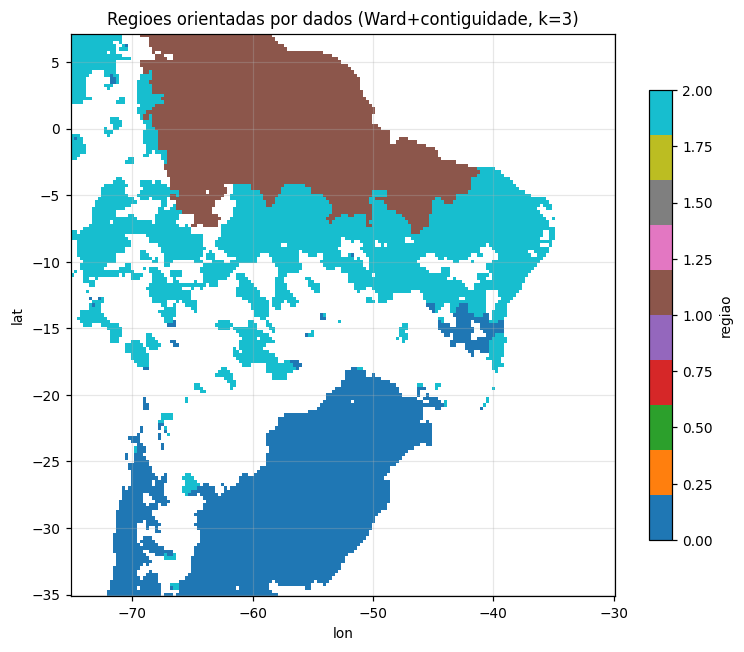

In [3]:
conn=grid_to_graph(ny,nx,mask=mask2d)                          # adjacencia entre pixels mascarados
sil=[]
for k in range(3,9):
    lab=AgglomerativeClustering(n_clusters=k,connectivity=conn,linkage='ward').fit_predict(Xs)
    s=silhouette_score(Xs,lab,sample_size=2500,random_state=0)
    sil.append((k,round(s,3)))
tab_sil=pd.DataFrame(sil,columns=['k','silhueta']); print(tab_sil.to_string(index=False))
kbest=int(tab_sil.loc[tab_sil.silhueta.idxmax(),'k'])
labels=AgglomerativeClustering(n_clusters=kbest,connectivity=conn,linkage='ward').fit_predict(Xs)
print('k escolhido (max silhueta):',kbest)
region=np.full((ny,nx),-1,int); region[mask2d]=labels
fig,ax=plt.subplots(figsize=(7,6))
im=ax.pcolormesh(lons,lats,np.where(region>=0,region,np.nan),cmap='tab10',shading='auto')
ax.set_title(f'Regioes orientadas por dados (Ward+contiguidade, k={kbest})'); plt.colorbar(im,ax=ax,shrink=0.8,label='regiao')
ax.set_xlabel('lon'); ax.set_ylabel('lat'); plt.tight_layout(); plt.show()

## 3. Validacao: indice regional x Nino 3.4 (lead, sinal, estacao)

Para cada regiao: indice = media de area (peso cos(lat)) da anomalia mensal de chuva; correlacao defasada vs SSTA do Nino 3.4 por estacao -> lead de pico, sinal e |r|.

In [4]:
# recarrega cubo mensal de chuva + Nino mensal (p/ indices regionais)
LAT=F.BRAZIL_BOX['lat']; LON=F.BRAZIL_BOX['lon']; t0=time.time()
das=[xr.open_zarr(str(F.ZARR/'regridded'/f'chirps_p25_{yv}.zarr')).sel(lat=slice(*LAT),lon=slice(*LON))['precip'] for yv in range(Y0,Y1+1) if glob.glob(str(F.ZARR/'regridded'/f'chirps_p25_{yv}.zarr'))]
pr=xr.concat(das,'time').sortby('time').sel(time=slice(PERIODO[0],PERIODO[1]))
mo=pr.resample(time='MS').mean().transpose('time','lat','lon').load()
V=mo.values; tw=pd.DatetimeIndex(mo['time'].values); mm=tw.month.values
Rm=np.full_like(V,np.nan)
for kk in range(1,13):
    i=mm==kk; muu=np.nanmean(V[i],0); sg=np.nanstd(V[i],0); Rm[i]=(V[i]-muu)/np.where(sg>0,sg,np.nan)
bb=F.load_physics_backbone(base='full').loc[PERIODO[0]:PERIODO[1]]
ss=bb['nino34_ssta'].resample('MS').mean()
yv=((ss-ss.groupby(ss.index.month).transform('mean'))/ss.groupby(ss.index.month).transform('std')).reindex(tw).values
wlat=np.cos(np.deg2rad(lats))[:,None]*np.ones((1,nx))
print('cubo mensal:',Rm.shape,'| t=%.1fs'%(time.time()-t0))

cubo mensal: (532, 169, 181) | t=10.5s


In [5]:
def best_lag(idx,yv,season):
    sm=np.isin(mm,SEASONS[season]); best=(np.nan,np.nan,np.nan)
    for L in LAGS:
        xs=pd.Series(yv).shift(L).values; m=np.isfinite(xs)&np.isfinite(idx)&sm
        if m.sum()<24: continue
        r=np.corrcoef(xs[m],idx[m])[0,1]
        if np.isnan(best[1]) or abs(r)>abs(best[1]): best=(L,r, m.sum())
    return best
rows=[]
for rg in range(kbest):
    pm=(region==rg)
    w=np.where(pm,wlat,0.0); wsum=w.sum()
    idx=np.array([np.nansum(Rm[t]*w)/wsum for t in range(Rm.shape[0])])  # indice regional
    npix=int(pm.sum()); latc=float(lats[np.where(pm.any(1))[0]].mean()); lonc=float(lons[np.where(pm.any(0))[0]].mean())
    best_s=None
    for s in SEASONS:
        L,r,n=best_lag(idx,yv,s)
        rows.append((rg,npix,round(latc,1),round(lonc,1),s,L,round(r,3) if not np.isnan(r) else np.nan,
                     'seca' if (not np.isnan(r) and r<0) else ('chuva' if not np.isnan(r) else '-')))
        if not np.isnan(r) and (best_s is None or abs(r)>abs(best_s[2])): best_s=(s,L,r)
tab_reg=report(pd.DataFrame(rows,columns=['regiao','n_pixels','lat_centro','lon_centro','estacao','lag_meses','r_pico','sinal']),'validacao_regioes_x_nino')
print(tab_reg.to_string(index=False))
xr.Dataset({'regiao':(('lat','lon'),region)},coords={'lat':lats,'lon':lons}).to_netcdf(OUT/'regioes_data_driven.nc')
print('[nc: regioes_data_driven.nc]')

[csv: phase4_E_regioes/validacao_regioes_x_nino.csv]
 regiao  n_pixels  lat_centro  lon_centro estacao  lag_meses  r_pico sinal
      0      3895       -22.5       -56.2     DJF          0   0.417 chuva
      0      3895       -22.5       -56.2     MAM          1   0.479 chuva
      0      3895       -22.5       -56.2     JJA          1   0.256 chuva
      0      3895       -22.5       -56.2     SON          0   0.445 chuva
      1      3961        -0.4       -55.2     DJF          1  -0.666  seca
      1      3961        -0.4       -55.2     MAM          0  -0.346  seca
      1      3961        -0.4       -55.2     JJA          1  -0.563  seca
      1      3961        -0.4       -55.2     SON          3  -0.587  seca
      2      4562        -9.6       -55.0     DJF          1  -0.371  seca
      2      4562        -9.6       -55.0     MAM          2  -0.411  seca
      2      4562        -9.6       -55.0     JJA          5  -0.322  seca
      2      4562        -9.6       -55.0     S

In [6]:
# Resumo: estacao/lag/sinal de pico por regiao (a 'carteira de identidade' de cada regiao)
ident=(tab_reg.dropna(subset=['r_pico']).loc[tab_reg.groupby('regiao')['r_pico'].apply(lambda s:s.abs().idxmax())]
       [['regiao','n_pixels','lat_centro','lon_centro','estacao','lag_meses','r_pico','sinal']])
ident=report(ident.sort_values('regiao'),'identidade_regioes')
print('IDENTIDADE DE CADA REGIAO (estacao e lag de pico):'); print(ident.to_string(index=False))

[csv: phase4_E_regioes/identidade_regioes.csv]
IDENTIDADE DE CADA REGIAO (estacao e lag de pico):
 regiao  n_pixels  lat_centro  lon_centro estacao  lag_meses  r_pico sinal
      0      3895       -22.5       -56.2     MAM          1   0.479 chuva
      1      3961        -0.4       -55.2     DJF          1  -0.666  seca
      2      4562        -9.6       -55.0     SON          3  -0.424  seca


## Interpretacao

`identidade_regioes.csv` da, para cada regiao descoberta, a estacao e o lag (meses) de maior resposta ao Nino e o sinal (seca/chuva) - a leitura direta de **onde, quando e como** o El Nino atinge o Brasil, agora com regioes orientadas pelos dados em vez das caixas a mao. `validacao_regioes_x_nino.csv` traz o detalhe por estacao; `regioes_data_driven.nc` e o mapa de rotulos.

**Limites:** a contiguidade evita manchas soltas, mas k e escolhido por silhueta + bom senso; vale checar a estabilidade variando k. Continua triagem estatistica (associacao/defasagem), nao causalidade nem previsao.